# Mini Project — Exploratory Data Analysis on India's COVID-19 Data

**Goal:** Uncover state-wise trends, recovery rates, and vaccination progress in India's COVID-19 pandemic, using nothing but the tools from Module 1: NumPy, Pandas, and Matplotlib/Seaborn.

**Data sources** (both loaded live, no download needed):
- **Case data:** `imdevskp/covid-19-india-data` — daily state-wise confirmed/recovered/death counts, sourced from MoHFW and covid19india.org (30 Jan 2020 – 6 Aug 2020).
- **Vaccination data:** Our World in Data (OWID) — India's national vaccination totals (15 Jan 2021 onward).

**Workflow:** Load → Inspect → Clean → Explore (groupby/pivot) → Visualise (12 charts) → Summarise findings.


## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 20)

print("Ready.")

Ready.


## 2. Load the Data

We read both CSVs straight from their public GitHub URLs with `pd.read_csv()` — exactly the File I/O skill from Module 1.

In [ ]:
cases = pd.read_csv(
    "https://raw.githubusercontent.com/imdevskp/covid-19-india-data/master/complete.csv"
)
vax = pd.read_csv(
    "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/vaccinations/country_data/India.csv"
)

print("Cases shape:", cases.shape)
print("Vaccination shape:", vax.shape)
cases.head()

Cases shape: (4692, 10)
Vaccination shape: (1250, 8)


,Date,Name of State / UT,Latitude,Longitude,Total Confirmed cases,Death,Cured/Discharged/Migrated,New cases,New deaths,New recovered
0,2020-01-30,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
1,2020-01-31,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
2,2020-02-01,Kerala,10.8505,76.2711,2.0,0,0.0,1,0,0
3,2020-02-02,Kerala,10.8505,76.2711,3.0,0,0.0,1,0,0
4,2020-02-03,Kerala,10.8505,76.2711,3.0,0,0.0,0,0,0


In [ ]:
vax.shape

## 3. Inspect Before Touching Anything

Always check shape, dtypes, and missing values first — this tells you exactly what cleaning is needed.

In [ ]:
cases.dtypes

Date                             str
Name of State / UT               str
Latitude                     float64
Longitude                    float64
Total Confirmed cases        float64
Death                            str
Cured/Discharged/Migrated    float64
New cases                      int64
New deaths                     int64
New recovered                  int64
dtype: object

In [ ]:
cases.isna().sum()

Date                         0
Name of State / UT           0
Latitude                     0
Longitude                    0
Total Confirmed cases        0
Death                        0
Cured/Discharged/Migrated    0
New cases                    0
New deaths                   0
New recovered                0
dtype: int64

In [ ]:
print("Number of unique state/UT names:", cases["Name of State / UT"].nunique())
sorted(cases["Name of State / UT"].unique())

Number of unique state/UT names: 40


['Andaman and Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chandigarh',
 'Chhattisgarh',
 'Dadra and Nagar Haveli and Daman and Diu',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Jammu and Kashmir',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Ladakh',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'Nagaland',
 'Odisha',
 'Puducherry',
 'Punjab',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'Telangana***',
 'Telengana',
 'Tripura',
 'Union Territory of Chandigarh',
 'Union Territory of Jammu and Kashmir',
 'Union Territory of Ladakh',
 'Uttar Pradesh',
 'Uttarakhand',
 'West Bengal']

Two problems jump out immediately:

1. **`Death` is stored as text (object), not a number** — likely because of stray characters somewhere in the column.
2. **The same state appears under multiple spellings**: `Telangana`, `Telengana`, and `Telangana***` are all the same state. Similarly, a few Union Territories are listed twice — once plainly (`Ladakh`) and once with a `"Union Territory of ..."` prefix.

This is exactly the kind of real-world messiness the handbook's Data Leakage/cleaning ideas prepare you for — we fix it before doing any analysis, never after.

## 4. Clean the Data

In [ ]:
# Rename to clean, snake_case column names
cases.columns = [
    "date", "state", "lat", "long", "confirmed",
    "deaths", "cured", "new_cases", "new_deaths", "new_recovered",
]

# Fix data types
cases["date"] = pd.to_datetime(cases["date"])
cases["deaths"] = pd.to_numeric(cases["deaths"], errors="coerce").fillna(0).astype(int)
cases["confirmed"] = cases["confirmed"].astype(int)
cases["cured"] = cases["cured"].astype(int)

# Fix inconsistent state names
name_fix = {
    "Telangana***": "Telangana",
    "Telengana": "Telangana",
    "Union Territory of Jammu and Kashmir": "Jammu and Kashmir",
    "Union Territory of Ladakh": "Ladakh",
    "Union Territory of Chandigarh": "Chandigarh",
}
cases["state"] = cases["state"].replace(name_fix)

# Drop any exact duplicate (date, state) rows this merge might create
cases = cases.drop_duplicates(subset=["date", "state"]).sort_values(["state", "date"]).reset_index(drop=True)

# A derived column: active cases = confirmed - deaths - recovered
cases["active"] = cases["confirmed"] - cases["deaths"] - cases["cured"]

print("Clean state count:", cases["state"].nunique())
cases.dtypes

Clean state count: 35


date             datetime64[us]
state                       str
lat                     float64
long                    float64
confirmed                 int64
deaths                    int64
cured                     int64
new_cases                 int64
new_deaths                int64
new_recovered             int64
active                    int64
dtype: object

In [ ]:
cases.isna().sum().sum()   # should be 0 -- fully clean now

np.int64(0)

## 5. National-Level Summary (groupby)

Let's aggregate all states together, per date, using `groupby` — the Module 1 workhorse.

In [ ]:
national = cases.groupby("date", as_index=False)[["confirmed", "deaths", "cured"]].sum()
national["recovery_rate"] = (national["cured"] / national["confirmed"] * 100).round(2)
national["death_rate"] = (national["deaths"] / national["confirmed"] * 100).round(2)
national["new_confirmed"] = national["confirmed"].diff().fillna(national["confirmed"])

national.tail()

,date,confirmed,deaths,cured,recovery_rate,death_rate,new_confirmed
181,2020-08-02,1750723,37364,1145629,65.44,2.13,54735.0
182,2020-08-03,1803695,38135,1186203,65.77,2.11,52972.0
183,2020-08-04,1855745,38938,1230509,66.31,2.10,52050.0
184,2020-08-05,1908254,39795,1282215,67.19,2.09,52509.0
185,2020-08-06,1964536,40699,1328336,67.62,2.07,56282.0


In [ ]:
latest_date = cases["date"].max()
latest_row = national.iloc[-1]

print(f"As of {latest_date.date()}:")
print(f"  Total confirmed : {latest_row['confirmed']:,}")
print(f"  Total recovered : {latest_row['cured']:,}")
print(f"  Total deaths    : {latest_row['deaths']:,}")
print(f"  Recovery rate   : {latest_row['recovery_rate']}%")
print(f"  Death rate      : {latest_row['death_rate']}%")

As of 2020-08-06:
  Total confirmed : 1,964,536
  Total recovered : 1,328,336
  Total deaths    : 40,699
  Recovery rate   : 67.62%
  Death rate      : 2.07%


## 6. State-Wise Snapshot (latest date)

In [ ]:
latest = cases[cases["date"] == latest_date].copy()
latest["recovery_rate"] = (latest["cured"] / latest["confirmed"] * 100).round(2)
latest["death_rate"] = (latest["deaths"] / latest["confirmed"] * 100).round(2)
latest = latest.sort_values("confirmed", ascending=False).reset_index(drop=True)

top10 = latest.head(10)
top10[["state", "confirmed", "deaths", "cured", "recovery_rate", "death_rate"]]

,state,confirmed,deaths,cured,recovery_rate,death_rate
0,Maharashtra,468265,16476,305521,65.25,3.52
1,Tamil Nadu,273460,4461,214815,78.55,1.63
2,Andhra Pradesh,186461,1681,104354,55.97,0.90
3,Karnataka,151449,2804,74679,49.31,1.85
4,Delhi,140232,4044,126116,89.93,2.88
5,Uttar Pradesh,104388,1857,60558,58.01,1.78
6,West Bengal,83800,1846,58962,70.36,2.20
7,Telangana,73050,589,52103,71.33,0.81
8,Gujarat,66669,2556,49433,74.15,3.83
9,Bihar,64770,355,42414,65.48,0.55


**pivot_table**: confirmed cases by state and month, so we can see when each state's outbreak accelerated.

In [ ]:
cases["month"] = cases["date"].dt.strftime("%Y-%m")
month_pivot = cases[cases["state"].isin(top10["state"].head(5))].pivot_table(
    values="new_cases", index="state", columns="month", aggfunc="sum", fill_value=0
)
month_pivot

month,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08
state,,,,,,
Andhra Pradesh,39,1292,2237,10322,116666,55904
Delhi,96,3342,15110,66612,49242,5829
Karnataka,82,452,2387,11373,104337,32817
Maharashtra,218,9699,55253,104715,241915,56467
Tamil Nadu,73,2088,19022,65040,153754,33482


## 7. Visualisations (12 charts)

We'll work through national trends, state comparisons, and relationships between metrics — using both Matplotlib and Seaborn, matching the Module 1 handbook patterns.

### Chart 1 — National cumulative trend

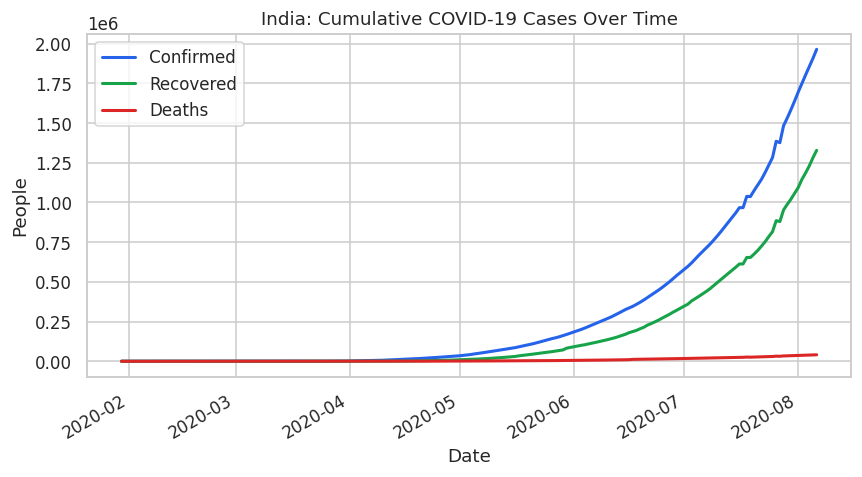

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(national["date"], national["confirmed"], label="Confirmed", color="#2563eb", lw=2)
ax.plot(national["date"], national["cured"], label="Recovered", color="#16a34a", lw=2)
ax.plot(national["date"], national["deaths"], label="Deaths", color="#dc2626", lw=2)
ax.set_title("India: Cumulative COVID-19 Cases Over Time")
ax.set_xlabel("Date"); ax.set_ylabel("People")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Chart 2 — Daily new confirmed cases

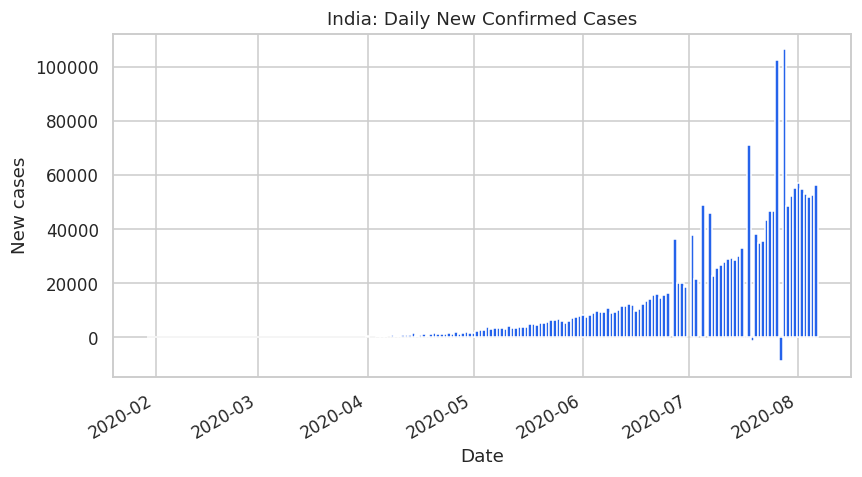

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(national["date"], national["new_confirmed"], color="#2563eb", width=1.0)
ax.set_title("India: Daily New Confirmed Cases")
ax.set_xlabel("Date"); ax.set_ylabel("New cases")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Chart 3 — Top 10 states by total confirmed cases

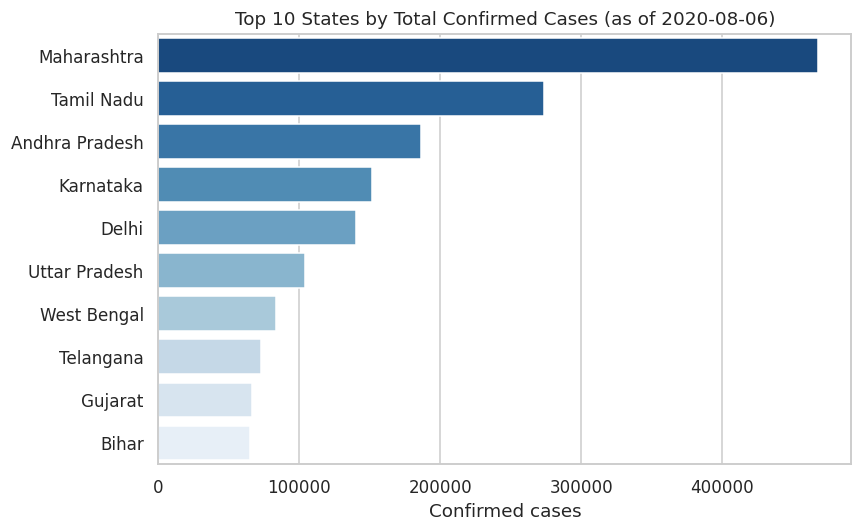

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top10, y="state", x="confirmed", hue="state", palette="Blues_r", legend=False, ax=ax)
ax.set_title(f"Top 10 States by Total Confirmed Cases (as of {latest_date.date()})")
ax.set_xlabel("Confirmed cases"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Chart 4 — Recovery rate of the 10 worst-hit states

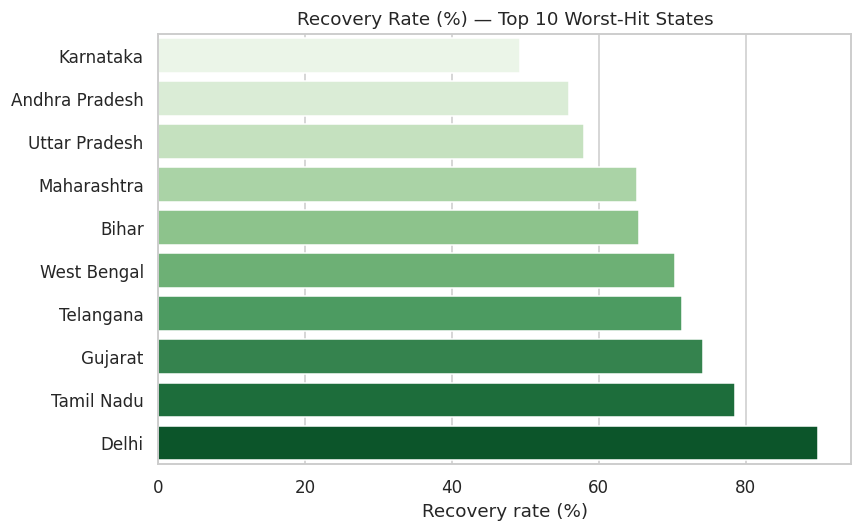

In [ ]:
top10_sorted = top10.sort_values("recovery_rate")
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top10_sorted, y="state", x="recovery_rate", hue="state", palette="Greens", legend=False, ax=ax)
ax.set_title("Recovery Rate (%) — Top 10 Worst-Hit States")
ax.set_xlabel("Recovery rate (%)"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Chart 5 — Confirmed-case trend for the top 5 states

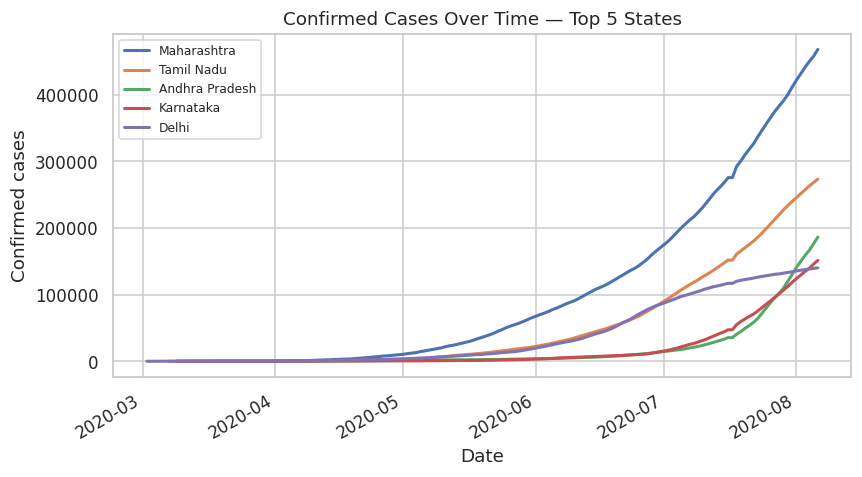

In [ ]:
top5_states = top10["state"].head(5).tolist()

fig, ax = plt.subplots(figsize=(8, 4.5))
for s in top5_states:
    sub = cases[cases["state"] == s]
    ax.plot(sub["date"], sub["confirmed"], label=s, lw=2)
ax.set_title("Confirmed Cases Over Time — Top 5 States")
ax.set_xlabel("Date"); ax.set_ylabel("Confirmed cases")
ax.legend(fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Chart 6 — Share of national cases by state (pie)

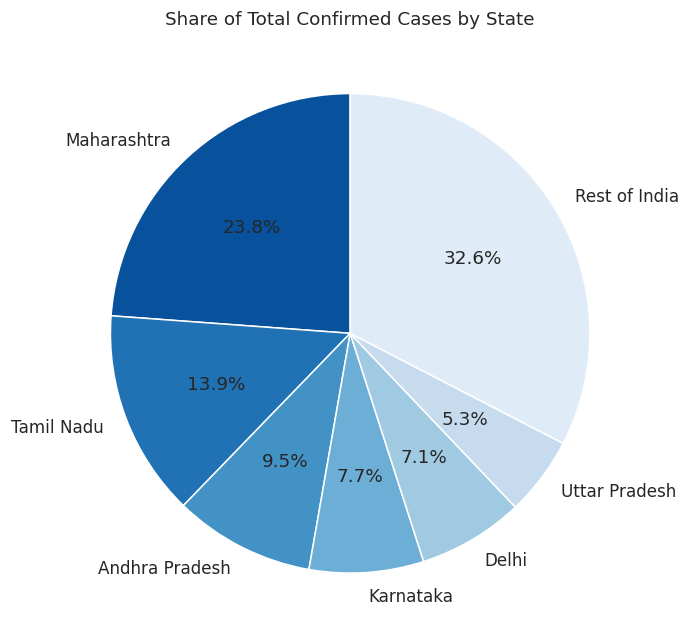

In [ ]:
top6 = latest.nlargest(6, "confirmed")[["state", "confirmed"]]
others = latest["confirmed"].sum() - top6["confirmed"].sum()
pie_labels = top6["state"].tolist() + ["Rest of India"]
pie_values = top6["confirmed"].tolist() + [others]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.pie(pie_values, labels=pie_labels, autopct="%1.1f%%", startangle=90,
       colors=sns.color_palette("Blues_r", 7))
ax.set_title("Share of Total Confirmed Cases by State")
plt.tight_layout()
plt.show()

### Chart 7 — National recovery-rate trend

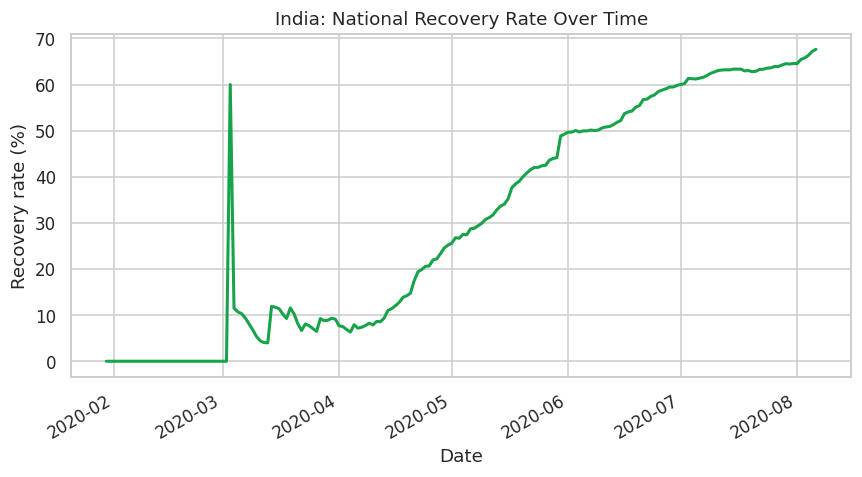

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(national["date"], national["recovery_rate"], color="#16a34a", lw=2)
ax.set_title("India: National Recovery Rate Over Time")
ax.set_xlabel("Date"); ax.set_ylabel("Recovery rate (%)")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Chart 8 — Recovery rate vs death rate, by state (bubble = case count)

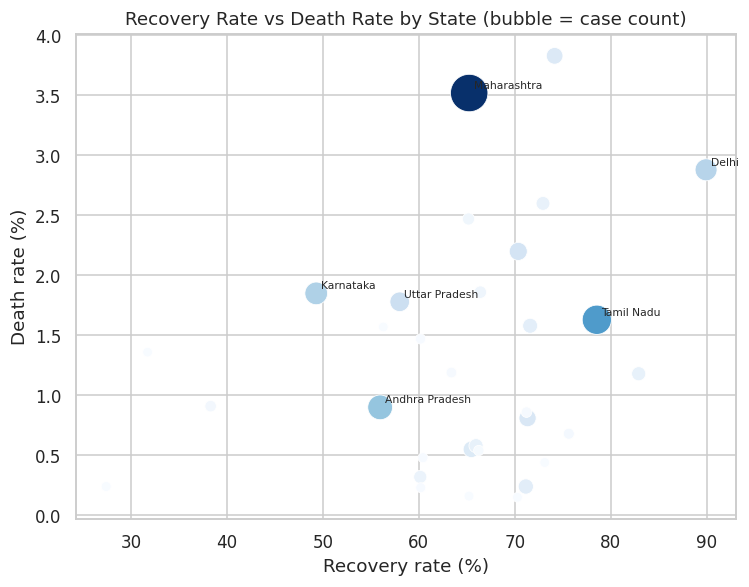

In [ ]:
sizeable = latest[latest["confirmed"] >= 1000]

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.scatterplot(data=sizeable, x="recovery_rate", y="death_rate", size="confirmed",
                 sizes=(40, 600), hue="confirmed", palette="Blues", legend=False, ax=ax)
for _, r in sizeable.nlargest(6, "confirmed").iterrows():
    ax.annotate(r["state"], (r["recovery_rate"], r["death_rate"]), fontsize=7,
                xytext=(3, 3), textcoords="offset points")
ax.set_title("Recovery Rate vs Death Rate by State (bubble = case count)")
ax.set_xlabel("Recovery rate (%)"); ax.set_ylabel("Death rate (%)")
plt.tight_layout()
plt.show()

### Chart 9 — Correlation heatmap of national metrics

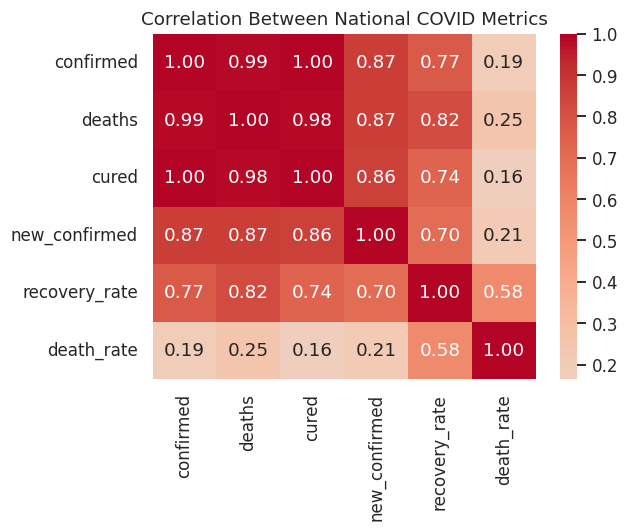

In [ ]:
corr_cols = ["confirmed", "deaths", "cured", "new_confirmed", "recovery_rate", "death_rate"]
corr = national[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Between National COVID Metrics")
plt.tight_layout()
plt.show()

### Chart 10 — Spread of daily new cases, by month (boxplot)

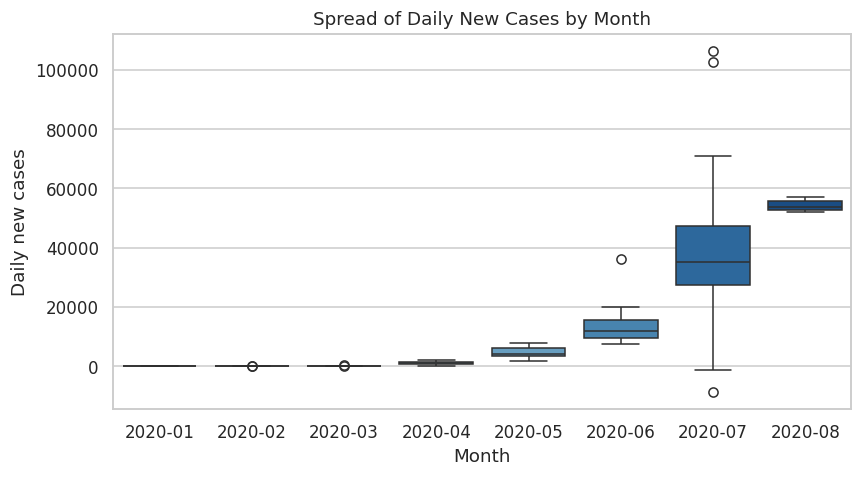

In [ ]:
national["month"] = national["date"].dt.strftime("%Y-%m")

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=national, x="month", y="new_confirmed", hue="month", palette="Blues", legend=False, ax=ax)
ax.set_title("Spread of Daily New Cases by Month")
ax.set_xlabel("Month"); ax.set_ylabel("Daily new cases")
plt.tight_layout()
plt.show()

### Chart 11 — India's vaccination progress (2021-2024)

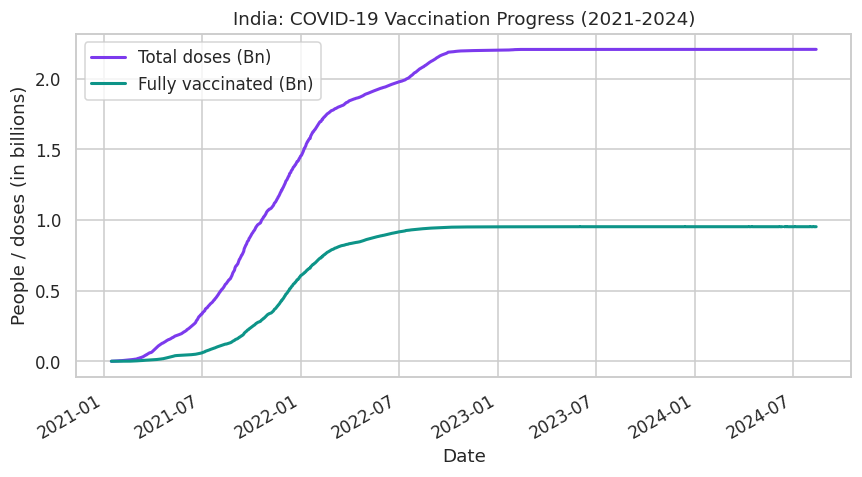

In [ ]:
vax["date"] = pd.to_datetime(vax["date"])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(vax["date"], vax["total_vaccinations"] / 1e9, label="Total doses (Bn)", color="#7c3aed", lw=2)
ax.plot(vax["date"], vax["people_fully_vaccinated"] / 1e9, label="Fully vaccinated (Bn)", color="#0d9488", lw=2)
ax.set_title("India: COVID-19 Vaccination Progress (2021-2024)")
ax.set_xlabel("Date"); ax.set_ylabel("People / doses (in billions)")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Chart 12 — The 10 least-affected states/UTs

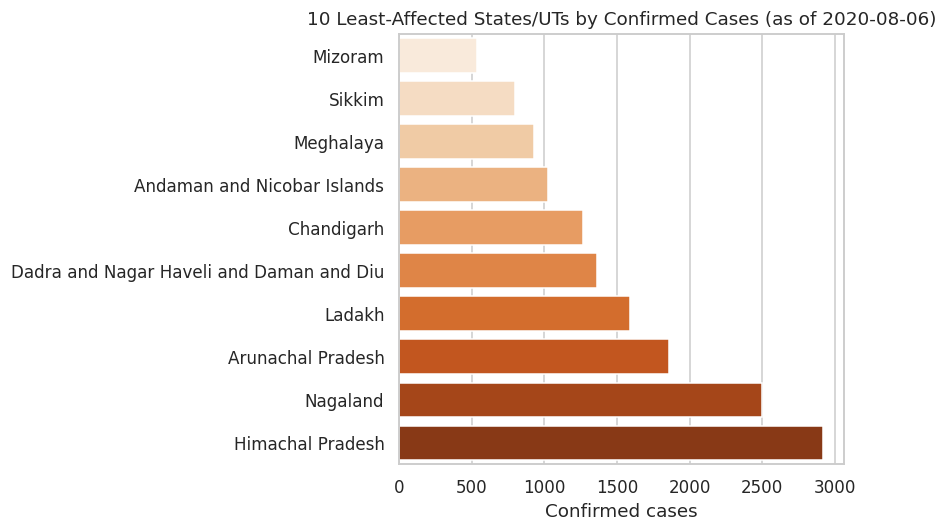

In [ ]:
bottom10 = latest[latest["confirmed"] > 0].nsmallest(10, "confirmed")

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=bottom10, y="state", x="confirmed", hue="state", palette="Oranges", legend=False, ax=ax)
ax.set_title(f"10 Least-Affected States/UTs by Confirmed Cases (as of {latest_date.date()})")
ax.set_xlabel("Confirmed cases"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 8. Save the Cleaned Dataset

One more File I/O practice rep — save the cleaned table so it can be reused without repeating the cleaning steps.

In [ ]:
cases.to_csv("cleaned_covid_india.csv", index=False)
print("Saved cleaned_covid_india.csv —", cases.shape[0], "rows.")

Saved cleaned_covid_india.csv — 4692 rows.


## 9. Written Summary

**Coverage.** The dataset tracks 35 states/UTs (after cleaning up duplicate spellings) across 186 days, from 30 January 2020 to 6 August 2020 — India's first COVID-19 wave.

**National picture.** By the end of the data window, India had recorded roughly **19.6 lakh (1.96 million)** confirmed cases, about **13.3 lakh** recoveries, and around **40,700** deaths — a national recovery rate near **68%** and a death rate near **2.1%**. The daily new-case count was still climbing sharply at the end of the window (peaking around **106,000 new cases in a single day** in late July 2020), which tells us the first wave had not yet crested by the point this dataset ends.

**State-wise concentration.** The outbreak was heavily concentrated: **Maharashtra** alone accounted for close to a quarter of all national cases, with **Tamil Nadu, Andhra Pradesh, Karnataka, and Delhi** rounding out the top five. Together, the top 6 states held the large majority of total cases — the pandemic was never evenly spread across India.

**Recovery varied a lot by state.** **Delhi** stands out with a recovery rate near **90%**, well ahead of other high-case states, while states like **Karnataka** were still under **50%** recovered at this snapshot — a sign that Karnataka's outbreak was comparatively newer/faster-growing relative to how many people had had time to recover.

**Death rate also varied.** Among the worst-hit states, **Gujarat** had the highest death rate at nearly **3.8%**, noticeably above the national average, while lower-case states like **Bihar** and **Telangana** had rates under **1%** — a pattern worth investigating further (health infrastructure, age demographics, and testing intensity would all be reasonable next questions).

**Vaccination (a later chapter of the same story).** India's vaccination drive began in January 2021, months after this case dataset ends. By mid-2024, national records show over **2.2 billion vaccine doses** administered and **950+ million people fully vaccinated** — illustrating the scale of the follow-up public health response after the wave captured in this dataset.

**Caveats.** This is state-bulletin-sourced case data — it inherits any inconsistencies in how individual states reported numbers (hence the name-spelling and text-formatted `Death` column issues we fixed). Recovery/death rates calculated this way are simple ratios of cumulative totals, not adjusted for reporting lag, so they should be read as directional trends rather than precise clinical outcome rates.
